# Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timezone
from pathlib import Path


In [2]:
articles = pd.read_csv("../data/articles_metadata.csv")
clicks = pd.read_csv("../data/clicks_sample.csv")
embeddings = pd.read_pickle("../data/articles_embeddings.pickle")

print("Articles")
display(articles.head())
print("\nClicks")
display(clicks.head())

Articles


,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162



Clicks


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


In [6]:
len(embeddings)

364047

## Articles metadata

In [10]:
articles.info()

<class 'pandas.DataFrame'>
RangeIndex: 364047 entries, 0 to 364046
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   article_id     364047 non-null  int64
 1   category_id    364047 non-null  int64
 2   created_at_ts  364047 non-null  int64
 3   publisher_id   364047 non-null  int64
 4   words_count    364047 non-null  int64
dtypes: int64(5)
memory usage: 13.9 MB


In [4]:
print(f"Date min: {articles['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).min()}")
print(f"Date max: {articles['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).max()}")
print(f"Number of unique articles: {articles['article_id'].nunique()}")
print(f"Number of unique category: {articles['category_id'].nunique()}")
print(f"Number of unique publishers: {articles['publisher_id'].nunique()}")


Date min: 2006-09-27 11:14:35
Date max: 2018-03-13 12:12:30
Number of unique articles: 364047
Number of unique category: 461
Number of unique publishers: 1


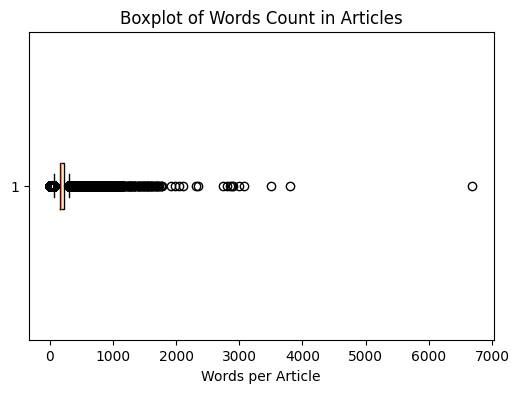

In [15]:
plt.figure(figsize=(6, 4))
plt.boxplot(articles['words_count'], vert=False)
plt.xlabel('Words per Article')
plt.title('Boxplot of Words Count in Articles')
plt.show()

In [16]:
articles.describe()

,article_id,category_id,created_at_ts,publisher_id,words_count
count,364047.000000,364047.000000,3.640470e+05,364047.0,364047.000000
mean,182023.000000,283.108239,1.474070e+12,0.0,190.897727
std,105091.461061,136.723470,4.293038e+10,0.0,59.502766
min,0.000000,0.000000,1.159356e+12,0.0,0.000000
25%,91011.500000,199.000000,1.444925e+12,0.0,159.000000
50%,182023.000000,301.000000,1.489422e+12,0.0,186.000000
75%,273034.500000,399.000000,1.509891e+12,0.0,218.000000
max,364046.000000,460.000000,1.520943e+12,0.0,6690.000000


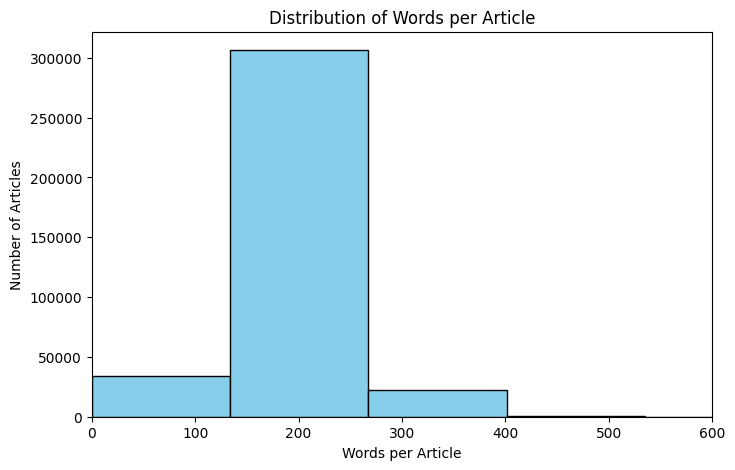

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(articles['words_count'], bins=50, color='skyblue', edgecolor='black')
plt.xlim([0,600])
plt.xlabel('Words per Article')
plt.ylabel('Number of Articles')
plt.title('Distribution of Words per Article')
plt.show()

In [24]:
# Missing values
print("Articles missing values:")
print(articles.isnull().sum())

Articles missing values:
article_id       0
category_id      0
created_at_ts    0
publisher_id     0
words_count      0
dtype: int64


In [25]:
# Get duplicates
duplicates = articles[articles.duplicated(subset='article_id', keep=False)]
print(f"Number of duplicate articles: {len(duplicates)}")
print("Duplicate article IDs:")
print(duplicates['article_id'].unique())

Number of duplicate articles: 0
Duplicate article IDs:
[]


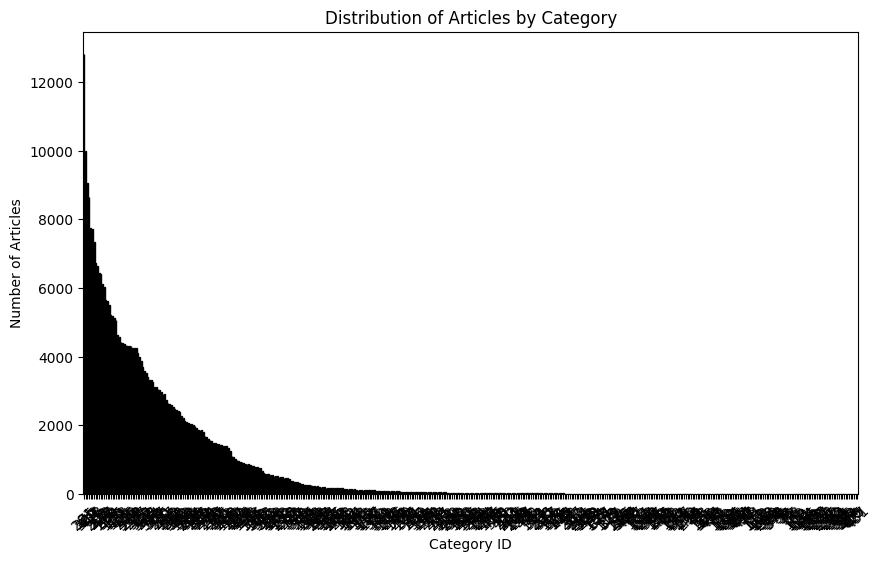

In [10]:
# Distribution of articles per categories
plt.figure(figsize=(10, 6))
articles['category_id'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Category ID')
plt.ylabel('Number of Articles')
plt.title('Distribution of Articles by Category')
plt.xticks(rotation=45)
plt.show()

In [ ]:
articles['category_id'].value_counts().describe()

count      461.000000
mean       789.689805
std       1712.041053
min          1.000000
25%          7.000000
50%         36.000000
75%        520.000000
max      12817.000000
Name: count, dtype: float64

category_id
281    12817
375    10005
399     9049
412     8648
431     7759
       ...  
341        1
121        1
335        1
131        1
0          1
Name: article_id, Length: 461, dtype: int64

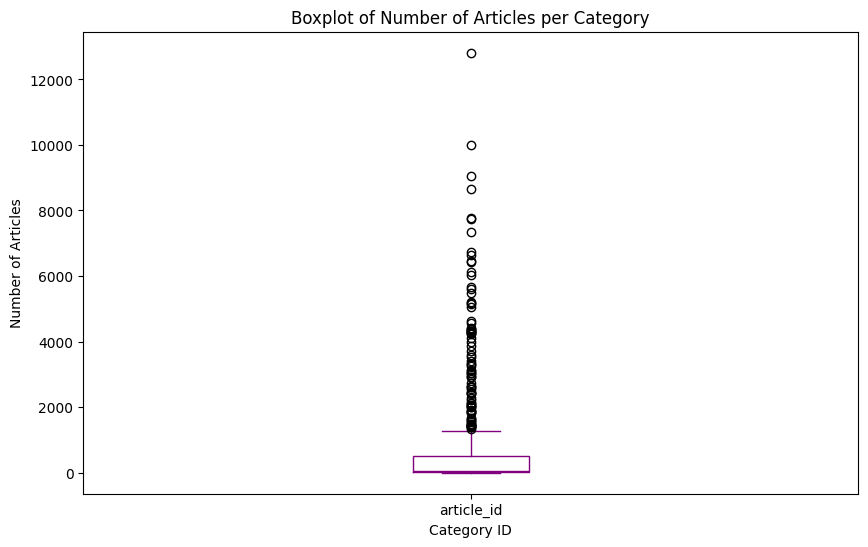

In [86]:
# vertical box plot the number of articles per category
categories = articles.groupby('category_id')['article_id'].count().sort_values(ascending=False)
display(categories)
plt.figure(figsize=(10, 6))
categories.plot(kind='box', color='purple')
plt.xlabel('Category ID')
plt.ylabel('Number of Articles')
plt.title('Boxplot of Number of Articles per Category')
plt.show()


Text(0.5, 1.0, 'Boxplot of Number of Articles per Category')

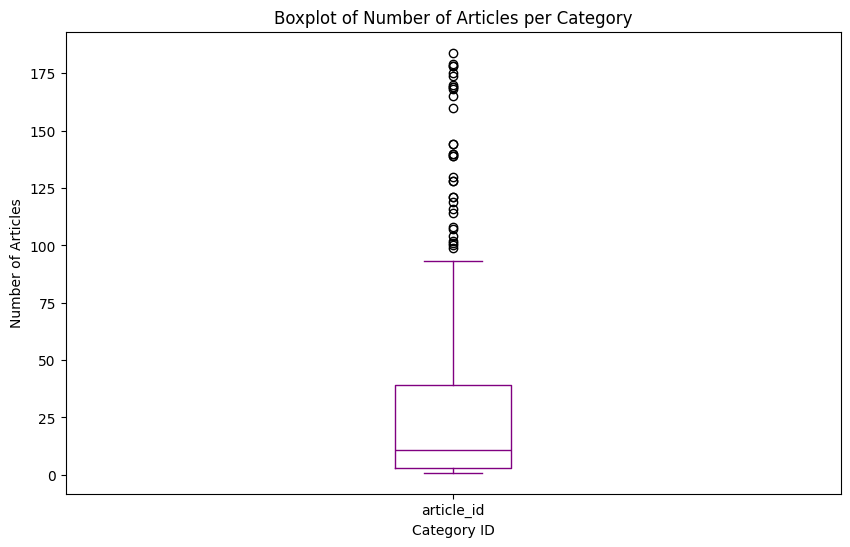

In [95]:
# boxplot the number of articles per category after removing the outliers (>5000 articles)
no_outiliers = categories[categories < 200]
plt.figure(figsize=(10, 6))
no_outiliers.plot(kind='box', color='purple')
plt.xlabel('Category ID')
plt.ylabel('Number of Articles')
plt.title('Boxplot of Number of Articles per Category')

In [96]:
# Average of articles per category
articles.groupby('category_id')['article_id'].count().describe()

count      461.000000
mean       789.689805
std       1712.041053
min          1.000000
25%          7.000000
50%         36.000000
75%        520.000000
max      12817.000000
Name: article_id, dtype: float64

Number of categories with minimum 36 articles: 231
Number of categories with minimum 1 article: 48


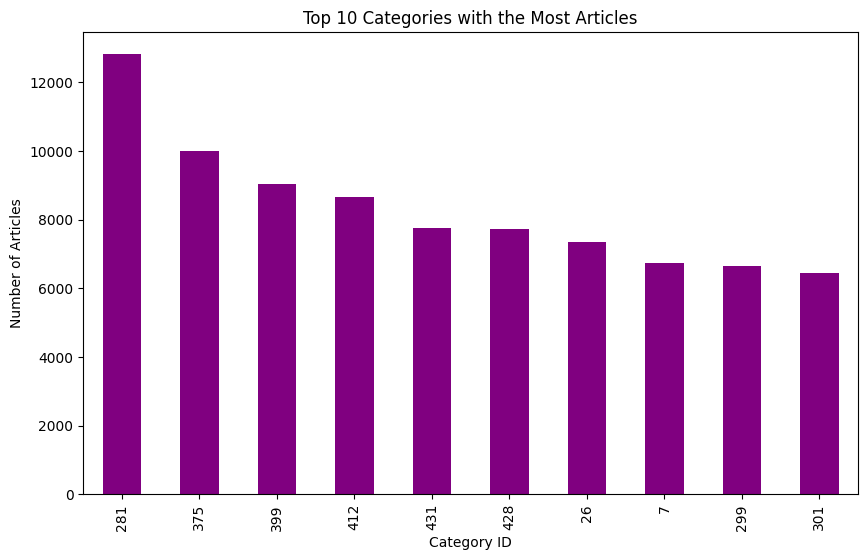

Number of categories with more than 1 and less than 11 articles: 105


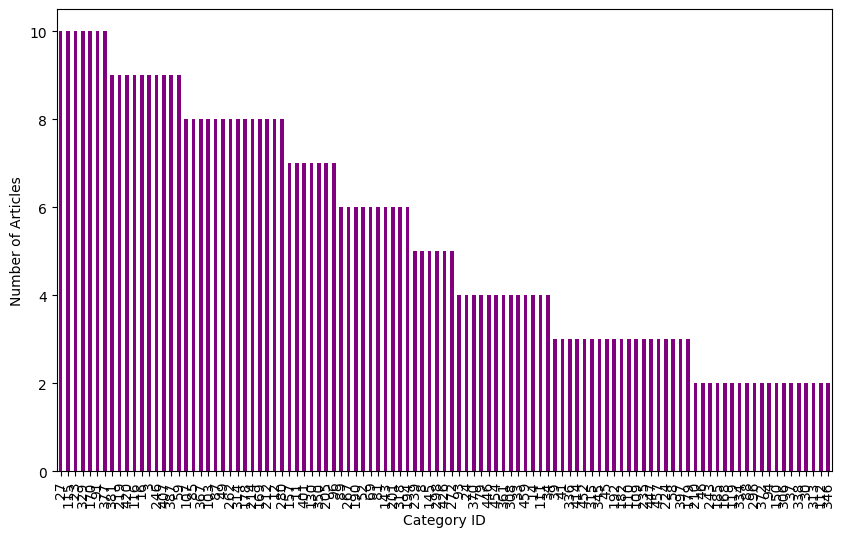

In [104]:
# Number of categories with minimum 30 articles
categories_with_more_than_30_articles = categories[categories >= 36]
print(f"Number of categories with minimum 36 articles: {len(categories_with_more_than_30_articles)}")

cat_count = categories[categories == 1]
print(f"Number of categories with minimum 1 article: {len(cat_count)}")

# Plot the top 10 categories with the most articles
plt.figure(figsize=(10, 6))
categories_with_more_than_30_articles.head(10).plot(kind='bar', color='purple')
plt.xlabel('Category ID')
plt.ylabel('Number of Articles')
plt.title('Top 10 Categories with the Most Articles')
plt.show()

# Plot categories with more than one article and less than 11 articles
plt.figure(figsize=(10, 6))
categories_with_more_than_one_article = categories[categories > 1]
categories_with_less_than_11_articles = categories_with_more_than_one_article[categories_with_more_than_one_article < 11]
categories_with_less_than_11_articles.plot(kind='bar', color='purple')
plt.xlabel('Category ID')
plt.ylabel('Number of Articles')

# Coutn categories with more than one and less than 11 articles
cat_count = categories[categories > 1]
cat_count = cat_count[cat_count < 11]
print(f"Number of categories with more than 1 and less than 11 articles: {len(cat_count)}")

## Clicks sample

In [19]:
clicks.info()

<class 'pandas.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              1883 non-null   int64
 1   session_id           1883 non-null   int64
 2   session_start        1883 non-null   int64
 3   session_size         1883 non-null   int64
 4   click_article_id     1883 non-null   int64
 5   click_timestamp      1883 non-null   int64
 6   click_environment    1883 non-null   int64
 7   click_deviceGroup    1883 non-null   int64
 8   click_os             1883 non-null   int64
 9   click_country        1883 non-null   int64
 10  click_region         1883 non-null   int64
 11  click_referrer_type  1883 non-null   int64
dtypes: int64(12)
memory usage: 176.7 KB


In [105]:
print(f"Number of unique users: {clicks['user_id'].nunique()}")
print(f"Average of clicks per articles: {clicks['click_article_id'].value_counts().mean():.2f}")
print(f"Average of clicks per session per user: {clicks.groupby(['user_id', 'session_id'])['click_article_id'].count().mean():.2f}")
last_ts_ms = clicks["click_timestamp"].max()
last_date_utc = datetime.fromtimestamp(last_ts_ms / 1000, tz=timezone.utc).date()
print(f"The last click date is: {last_date_utc}")

print(clicks['user_id'].value_counts().describe())

Number of unique users: 707
Average of clicks per articles: 5.83
Average of clicks per session per user: 2.66
The last click date is: 2017-10-03
count    707.000000
mean       2.663366
std        1.457559
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       24.000000
Name: count, dtype: float64


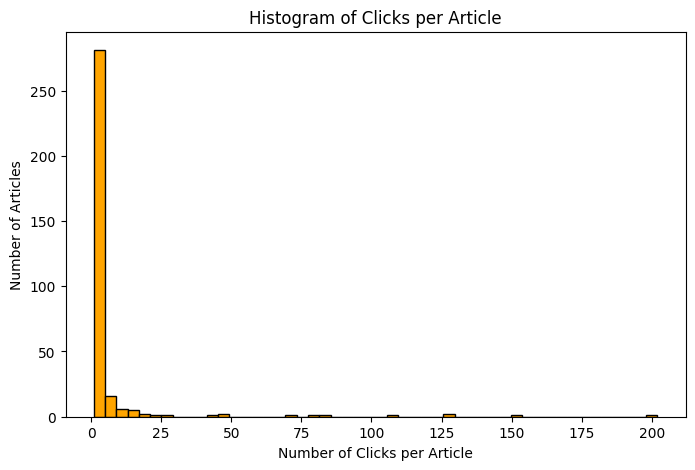

In [108]:
click_counts = clicks['click_article_id'].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(click_counts, bins=50, color='orange', edgecolor='black')
plt.xlabel('Number of Clicks per Article')
plt.ylabel('Number of Articles')
plt.title('Histogram of Clicks per Article')
plt.show()

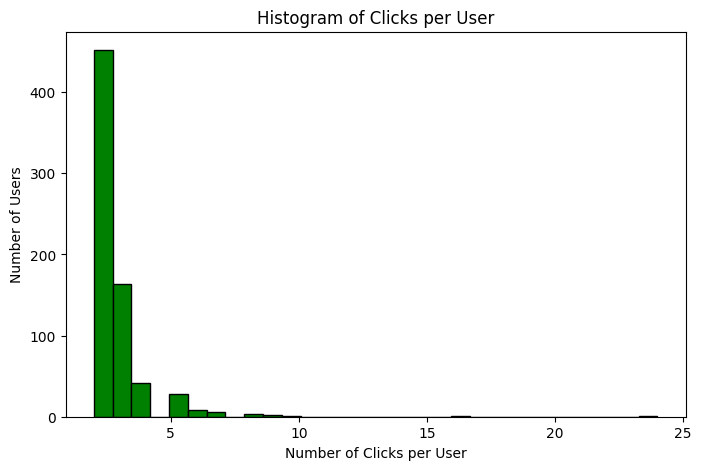

In [23]:
user_click_counts = clicks['user_id'].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(user_click_counts, bins=30, color='green', edgecolor='black')
plt.xlabel('Number of Clicks per User')
plt.ylabel('Number of Users')
plt.title('Histogram of Clicks per User')
plt.show()

In [29]:
# Missing values
print("Clicks missing values:")
print(clicks.isnull().sum())
# Get duplicates
click_duplicates = clicks[clicks.duplicated(subset=['user_id', 'click_article_id'], keep=False)]
print(f"Number of duplicate clicks: {len(click_duplicates)}")

Clicks missing values:
user_id                0
session_id             0
session_start          0
session_size           0
click_article_id       0
click_timestamp        0
click_environment      0
click_deviceGroup      0
click_os               0
click_country          0
click_region           0
click_referrer_type    0
dtype: int64
Number of duplicate clicks: 0


## Clicks

In [32]:
# Make a unique dataframe of clicks using data/clicks/*csv files
import glob
click_files = glob.glob("../data/clicks/*.csv")
clicks_full = pd.concat((pd.read_csv(f) for f in click_files), ignore_index=True)
print(f"Total clicks in full dataset: {len(clicks_full)}")
print(clicks_full.info())

Total clicks in full dataset: 2988181
<class 'pandas.DataFrame'>
RangeIndex: 2988181 entries, 0 to 2988180
Data columns (total 12 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   user_id              object
 1   session_id           object
 2   session_start        object
 3   session_size         object
 4   click_article_id     object
 5   click_timestamp      object
 6   click_environment    object
 7   click_deviceGroup    object
 8   click_os             object
 9   click_country        object
 10  click_region         object
 11  click_referrer_type  object
dtypes: object(12)
memory usage: 273.6+ MB
None


In [33]:
# Find if missing values in clicks_full
print("Full Clicks missing values:")
print(clicks_full.isnull().sum())

# Find duplicates in clicks_full
print(f"Number of duplicate clicks in full dataset: {clicks_full.duplicated().sum()}")

Full Clicks missing values:
user_id                0
session_id             0
session_start          0
session_size           0
click_article_id       0
click_timestamp        0
click_environment      0
click_deviceGroup      0
click_os               0
click_country          0
click_region           0
click_referrer_type    0
dtype: int64
Number of duplicate clicks in full dataset: 0


In [33]:
# Optimize DF
# Define timestamps columns
timestamp_cols = ["session_start", "click_timestamp"]

# Convert timestamp columns to datetime and numeric types to best integer type to save memory
clicks_full[timestamp_cols] = clicks_full[timestamp_cols].apply(pd.to_datetime, unit='ms')
clicks_full['user_id'] = clicks_full['user_id'].astype('int32')
clicks_full['click_article_id'] = clicks_full['click_article_id'].astype('int32')

clicks_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 2988181 entries, 0 to 2988180
Data columns (total 12 columns):
 #   Column               Dtype         
---  ------               -----         
 0   user_id              int32         
 1   session_id           object        
 2   session_start        datetime64[ms]
 3   session_size         object        
 4   click_article_id     int32         
 5   click_timestamp      datetime64[ms]
 6   click_environment    object        
 7   click_deviceGroup    object        
 8   click_os             object        
 9   click_country        object        
 10  click_region         object        
 11  click_referrer_type  object        
dtypes: datetime64[ms](2), int32(2), object(8)
memory usage: 250.8+ MB


In [34]:
# Number of unique users
print(f'Total users: {clicks_full["user_id"].nunique()}')
# Number of unique sessions
print(f'Total sessions: {clicks_full["session_id"].nunique()}')


Total users: 322897
Total sessions: 1048594


In [106]:
# Average clicks per user and per session
print(f"Average clicks per user: {clicks_full['user_id'].value_counts().mean():.2f}")
print(f"Average clicks per session: {clicks_full.groupby(['user_id', 'session_id'])['click_article_id'].count().mean():.2f}")
clicks_full['user_id'].value_counts().describe()

Average clicks per user: 9.04
Average clicks per session: 2.79


count    322801.000000
mean          9.036016
std          13.908189
min           1.000000
25%           2.000000
50%           4.000000
75%          10.000000
max         910.000000
Name: count, dtype: float64

### Temporal analysis of clicks

We summarize activity using `click_timestamp` (milliseconds since epoch, interpreted as UTC after `pd.to_datetime(..., unit="ms")`). Calendar day uses the date part of that instant; hour-of-day is therefore in **UTC**.

Click timestamp range: 2017-10-01 03:00:00.026000 → 2017-11-13 20:04:14.886000
Span: 43 calendar days


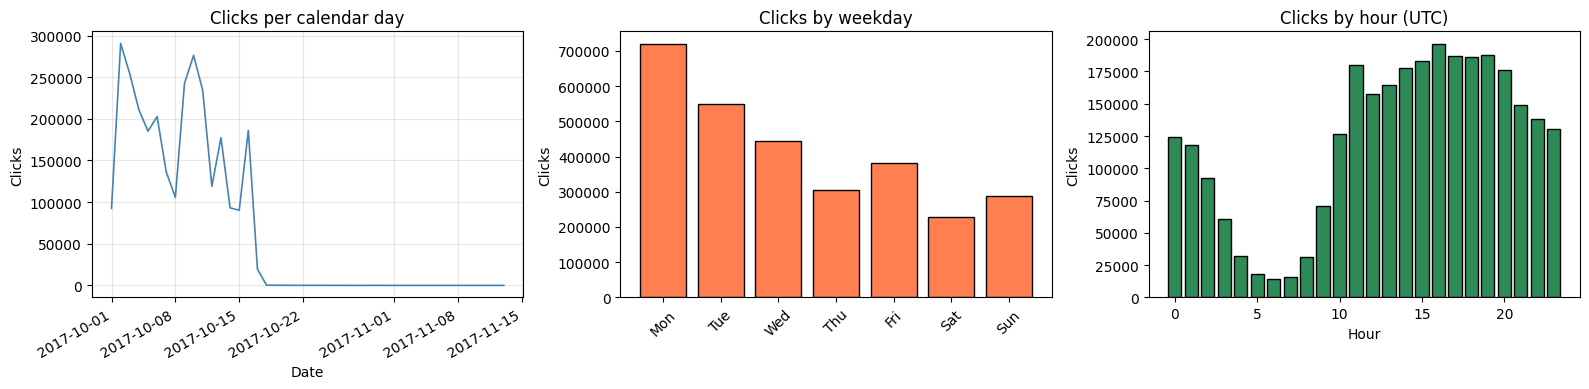

In [64]:
ct = clicks_full["click_timestamp"]
print(f"Click timestamp range: {ct.min()} → {ct.max()}")
span = ct.max() - ct.min()
print(f"Span: {span.days} calendar days")

daily = ct.dt.floor("D").value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

daily.plot(ax=axes[0], color="steelblue", linewidth=1.2)
axes[0].set_title("Clicks per calendar day")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Clicks")
axes[0].grid(alpha=0.3)

dow_order = list(range(7))
dow_counts = ct.dt.dayofweek.value_counts().reindex(dow_order, fill_value=0)
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar(dow_labels, dow_counts.values, color="coral", edgecolor="black")
axes[1].set_title("Clicks by weekday")
axes[1].set_ylabel("Clicks")
axes[1].tick_params(axis="x", rotation=45)

hour_order = list(range(24))
hour_counts = ct.dt.hour.value_counts().reindex(hour_order, fill_value=0)
axes[2].bar(hour_counts.index, hour_counts.values, color="seagreen", edgecolor="black")
axes[2].set_title("Clicks by hour (UTC)")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Clicks")

plt.tight_layout()
plt.show()

In [8]:
# When did the clicks stop on the full dataset ?
last_ts_ms = clicks_full["click_timestamp"].max()
print(f"The last click date is: {last_ts_ms}")


The last click date is: 2017-11-13 20:04:14.886000


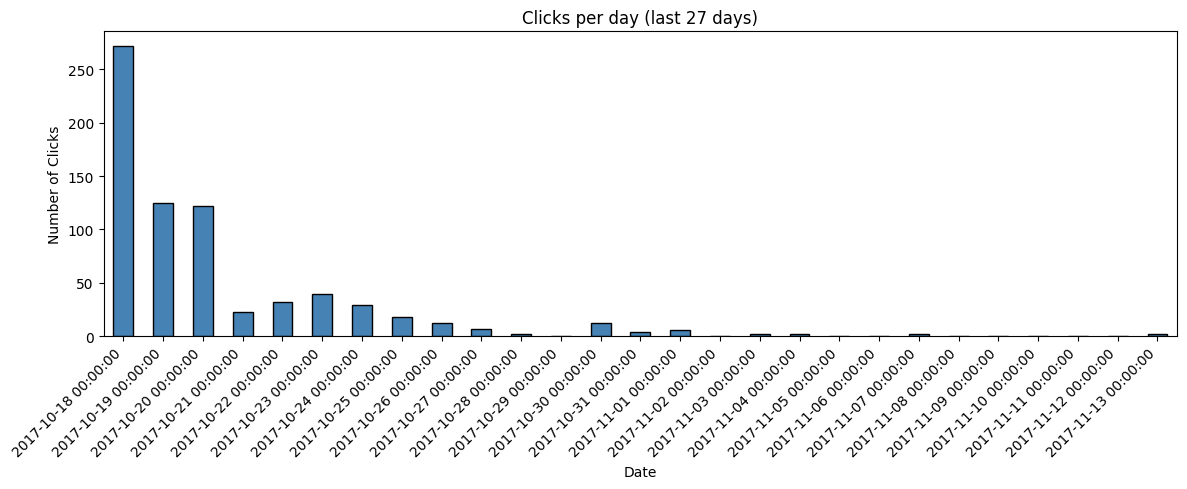

In [16]:
# Plot the distribution of clicks per day during the last 15 days using histogram
daily_counts = (
    clicks_full
    .set_index("click_timestamp")
    .resample("D")
    .size()
    .tail(27)
)
plt.figure(figsize=(12, 5))
daily_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Date")
plt.ylabel("Number of Clicks")
plt.title("Clicks per day (last 27 days)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [12]:
# number of clicks on the 2017-10-17
target_date = pd.to_datetime("2017-10-17").date()
n_clicks = (clicks_full["click_timestamp"].dt.date == target_date).sum()
print(f"Number of clicks on 2017-10-17: {n_clicks}")

# Number of clicks on the 2017-10-18
target_date = pd.to_datetime("2017-10-18").date()
n_clicks = (clicks_full["click_timestamp"].dt.date == target_date).sum()
print(f"Number of clicks on 2017-10-17: {n_clicks}")


Number of clicks on 2017-10-17: 19664
Number of clicks on 2017-10-17: 272


Session count: 1045146
Mean session length: 826.3086 s (13.7718 min) | 30.0000 s (median)
Average time between consecutive clicks: 461.4084 s (7.6901 min)
Average number of clicks per session: 2.7908397487049657


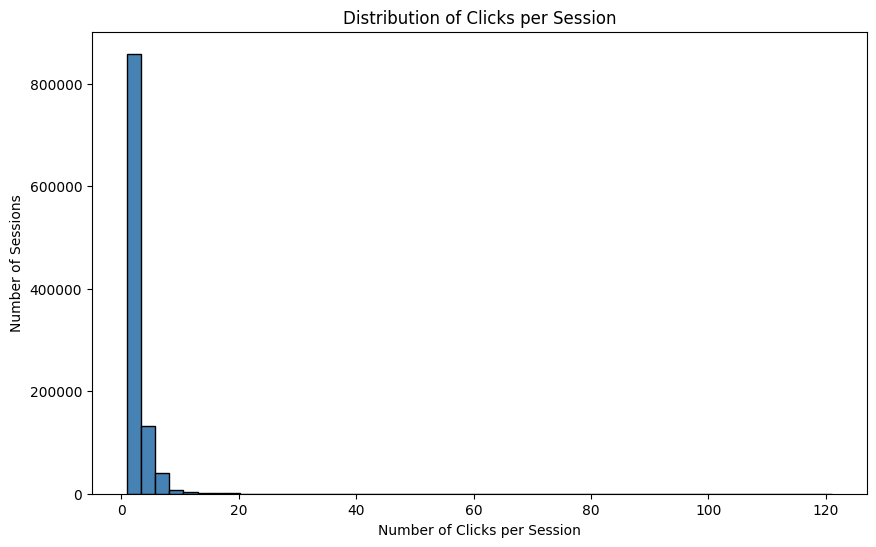

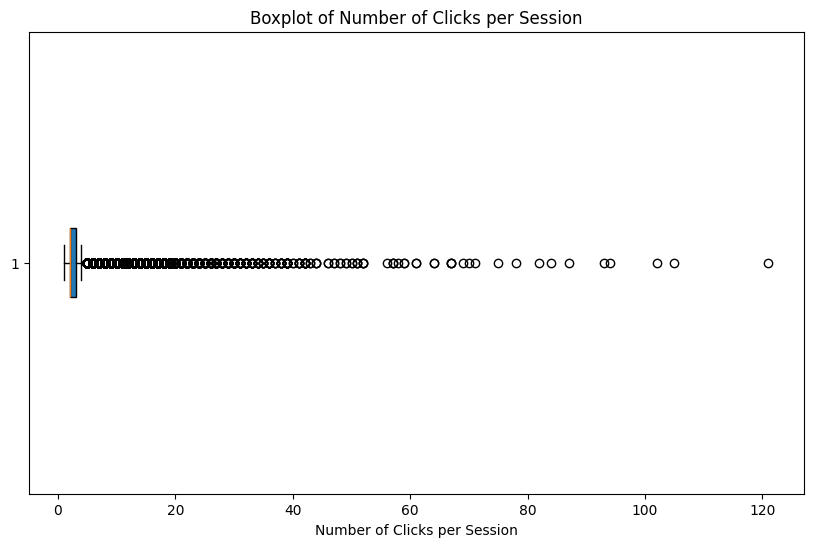

count    1.045146e+06
mean     2.790840e+00
std      1.689666e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      1.210000e+02
Name: click_timestamp, dtype: float64

In [53]:
# Session length: span from first to last click in the session (seconds; 0 for single-click sessions)
ts = clicks_full.groupby('session_id')['click_timestamp']
session_length_sec = (ts.max() - ts.min()).dt.total_seconds()
print(f"Session count: {len(session_length_sec)}")
print(f"Mean session length: {session_length_sec.mean():.4f} s ({session_length_sec.mean()/60:.4f} min) | {session_length_sec.median():.4f} s (median)")

# Average time between consecutive clicks within a session (seconds)
inter_click_seconds = clicks_full.groupby('session_id')['click_timestamp'].diff().dt.total_seconds()
average_inter_click = inter_click_seconds.mean()
print(f"Average time between consecutive clicks: {average_inter_click:.4f} s ({average_inter_click/60:.4f} min)")

# Get the average number of clicks per session
average_clicks_per_session = clicks_full.groupby('session_id')['click_timestamp'].count().mean()
print(f"Average number of clicks per session: {average_clicks_per_session}")

# Plot the distribution of clicks per session
plt.figure(figsize=(10, 6))
plt.hist(clicks_full.groupby('session_id')['click_timestamp'].count().dropna(), bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Number of Clicks per Session')
plt.ylabel('Number of Sessions')
plt.title('Distribution of Clicks per Session')
plt.show()

# Boxplot of number of clicks per session
plt.figure(figsize=(10, 6))
plt.boxplot(clicks_full.groupby('session_id')['click_timestamp'].count().dropna(), vert=False, patch_artist=True)
plt.xlabel('Number of Clicks per Session')
plt.title('Boxplot of Number of Clicks per Session')
plt.show()

display(clicks_full.groupby('session_id')['click_timestamp'].count().dropna().describe())


In [41]:
# Where are the users located?
# Agregate clicks by user_id and get the most common location
user_locations = clicks_full.groupby('user_id')['click_country'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
print(user_locations.value_counts().head(10))

click_country
1     309375
10      5879
11      3084
8        890
9        757
6        751
2        632
3        451
5        378
7        365
Name: count, dtype: int64


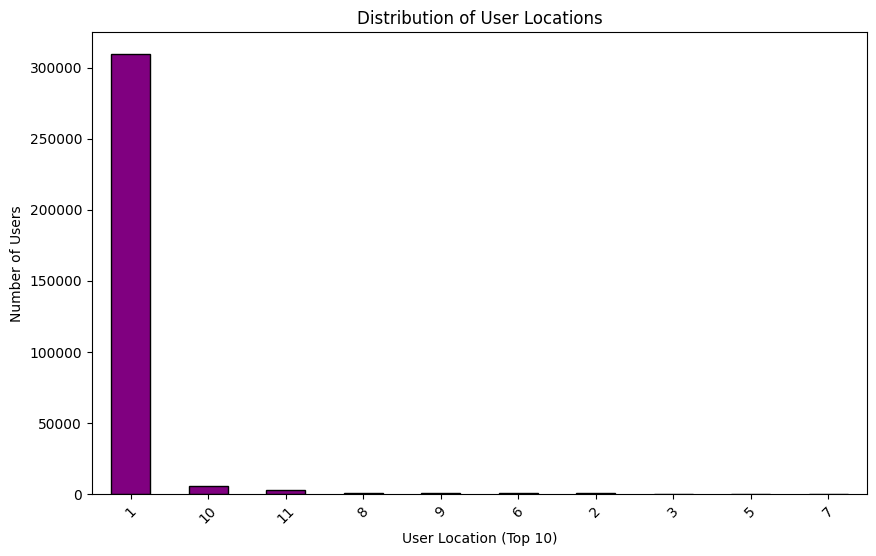

In [44]:
# Plot the distribution of user locations and colors for the regions
plt.figure(figsize=(10, 6))
user_locations.value_counts().head(10).plot(kind='bar', color='purple', edgecolor='black', figsize=(10, 6))
plt.xlabel('User Location (Top 10)')
plt.ylabel('Number of Users')
plt.title('Distribution of User Locations')
plt.xticks(rotation=45)
plt.show()

In [35]:
print(
    "Can a user have read the same article id multiple times in a session?"
    "\n===================================================================="
)
print(
    clicks_full.groupby(["user_id", "session_id", "click_article_id"])
    .size()
    .reset_index(name="count")
    .groupby("count")
    .size()
    .rename_axis(
        "N_times | Count of users who have clicked on the same article id once or more times in the same session",
        axis=0,
    ),
)

print(
    "Can a user can have read the same article id multiple times through different sessions?"
    "\n======================================================================================="
)
print(
    clicks_full.groupby(["user_id", "click_article_id"])
    .size()
    .reset_index(name="count")
    .groupby("count")
    .size()
    .rename_axis(
        "N_times | Count of users who have clicked on the same article id once or more times through different sessions",
        axis=0,
    ),
)

# We keep only (user_id, click_article_id) pairs that appear exactly once.
clicks_full = clicks_full[
    clicks_full.groupby(["user_id", "click_article_id"])["click_article_id"].transform("size") <= 1
]


Can a user have read the same article id multiple times in a session?
N_times | Count of users who have clicked on the same article id once or more times in the same session
1    2988181
dtype: int64
Can a user can have read the same article id multiple times through different sessions?
N_times | Count of users who have clicked on the same article id once or more times through different sessions
1     2916835
2       31459
3        1869
4         343
5          95
6          42
7          22
8          14
9           7
10          7
12          3
13          6
16          2
17          1
30          1
31          1
33          3
dtype: int64


In [36]:
# Articles popularity
article_popularity = clicks_full['click_article_id'].value_counts().reset_index()
article_popularity.columns = ['article_id', 'click_count']
print(article_popularity.head())


   article_id  click_count
0      160974        31390
1      272143        27705
2      336221        23379
3      234698        22689
4       96210        21138


## Merging DF

In [37]:
df = clicks_full.merge(articles, left_on='click_article_id', right_on='article_id', how='left')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2916835 entries, 0 to 2916834
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   user_id              int32         
 1   session_id           object        
 2   session_start        datetime64[ms]
 3   session_size         object        
 4   click_article_id     int32         
 5   click_timestamp      datetime64[ms]
 6   click_environment    object        
 7   click_deviceGroup    object        
 8   click_os             object        
 9   click_country        object        
 10  click_region         object        
 11  click_referrer_type  object        
 12  article_id           int64         
 13  category_id          int64         
 14  created_at_ts        int64         
 15  publisher_id         int64         
 16  words_count          int64         
dtypes: datetime64[ms](2), int32(2), int64(5), object(8)
memory usage: 356.1+ MB
None


In [14]:
df.head()

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,93863,1507865792177843,1507865792000,2,96210,1507865832925,4,3,2,1,21,2,96210,209,1507798791000,0,274
1,93863,1507865792177843,1507865792000,2,158094,1507865862925,4,3,2,1,21,2,158094,281,1507803751000,0,223
2,294036,1507865795185844,1507865795000,2,20691,1507865819095,4,3,20,1,9,2,20691,9,1507826236000,0,226
3,294036,1507865795185844,1507865795000,2,96210,1507865849095,4,3,20,1,9,2,96210,209,1507798791000,0,274
4,77136,1507865796257845,1507865796000,2,336245,1507866133178,4,3,2,1,25,2,336245,437,1507785531000,0,150


In [38]:
# keep data until 2017-10-17 included
df = df[df['click_timestamp'] <= pd.Timestamp('2017-10-17')]
df.info()

<class 'pandas.DataFrame'>
Index: 2896638 entries, 0 to 2916834
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   user_id              int32         
 1   session_id           object        
 2   session_start        datetime64[ms]
 3   session_size         object        
 4   click_article_id     int32         
 5   click_timestamp      datetime64[ms]
 6   click_environment    object        
 7   click_deviceGroup    object        
 8   click_os             object        
 9   click_country        object        
 10  click_region         object        
 11  click_referrer_type  object        
 12  article_id           int64         
 13  category_id          int64         
 14  created_at_ts        int64         
 15  publisher_id         int64         
 16  words_count          int64         
dtypes: datetime64[ms](2), int32(2), int64(5), object(8)
memory usage: 375.7+ MB


In [39]:
# show the values of the column publisher_id
print(f'Total publishers: {df["publisher_id"].nunique()}')
print(df['publisher_id'].value_counts())
# show the values of the column category_id
print(f'Total categories: {df["category_id"].nunique()}')
print(df['category_id'].value_counts())


Total publishers: 1
publisher_id
0    2896638
Name: count, dtype: int64
Total categories: 312
category_id
281    353928
375    260911
412    175487
437    153800
250    134913
        ...  
119         1
175         1
103         1
96          1
234         1
Name: count, Length: 312, dtype: int64


In [40]:
datetime_cols = ['session_start', 'click_timestamp', 'created_at_ts']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], unit='ms')

# COnvert numeric columns to best integer type to save memory
for col in df.columns:
    if col not in datetime_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce', downcast='integer')

df = df.drop(columns=['click_article_id'])

df.info()

<class 'pandas.DataFrame'>
Index: 2896638 entries, 0 to 2916834
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   user_id              int32         
 1   session_id           int64         
 2   session_start        datetime64[ms]
 3   session_size         int8          
 4   click_timestamp      datetime64[ms]
 5   click_environment    int8          
 6   click_deviceGroup    int8          
 7   click_os             int8          
 8   click_country        int8          
 9   click_region         int8          
 10  click_referrer_type  int8          
 11  article_id           int32         
 12  category_id          int16         
 13  created_at_ts        datetime64[ms]
 14  publisher_id         int8          
 15  words_count          int16         
dtypes: datetime64[ms](3), int16(2), int32(2), int64(1), int8(8)
memory usage: 165.7 MB


Recommender systems have a problem known as user cold-start, in which is hard do provide personalized recommendations for users with none or a very few number of consumed items, due to the lack of information to model their preferences.
For this reason, we are keeping in the dataset only users with at least 5 interactions.

In [ ]:
user_interactions_counts = df.groupby(['user_id', 'article_id']).size().groupby('user_id').size()
print(f'Total users: {user_interactions_counts.shape[0]}')
users_with_enough_interactions = user_interactions_counts[user_interactions_counts >= 5].reset_index()[['user_id']]
print(f'Users with at least 5 interactions: {users_with_enough_interactions.shape[0]}')
print(f'Total number of interactions for users with at least 5 interactions: {user_interactions_counts[user_interactions_counts >= 5].sum()}')

Total users: 321776
Users with at least 5 interactions: 158601
Total number of interactions for users with at least 5 interactions: 2470720


In [45]:
# filter the df to keep only the users with at least 5 interactions
df = df[df['user_id'].isin(users_with_enough_interactions['user_id'])]
print(f'Total number of interactions for users with at least 5 interactions: {df.shape[0]}')


Total number of interactions for users with at least 5 interactions: 2470720


In [46]:
# Persist the filtered dataset for reuse
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)
base = out_dir / "clicks_articles_merged"

try:
    df.to_parquet(base.with_suffix(".parquet"), index=False)
    print(f"Saved: {base.with_suffix('.parquet')}")
except Exception as e:
    df.to_csv(base.with_suffix(".csv.gz"), index=False, compression="gzip")
    print(f"Parquet unavailable ({type(e).__name__}). Saved: {base.with_suffix('.csv.gz')}")

Parquet unavailable (ArrowKeyError). Saved: ../data/processed/clicks_articles_merged.csv.gz


#### Split data

In [61]:
from collections import defaultdict

In [59]:
candidate_dates = pd.date_range(
    start=df["click_timestamp"].dt.date.min(),
    end=df["click_timestamp"].dt.date.max(),
    freq="D",
)

In [62]:
results_dict = defaultdict(list)
# Iterate over each candidate date to create train/test splits
for date in candidate_dates[1:]:
    # Filter the DataFrame for the current date
    train = df[df["click_timestamp"] < date]
    test = df[df["click_timestamp"] >= date]

    # Compute the number of clicks by user in the training and test sets
    train_clicks = train.groupby("user_id")["click_timestamp"].size()
    test_clicks = test.groupby("user_id")["click_timestamp"].size()

    # Identify users with at least 1 click in the training set and at least 5 clicks in the test set
    valid_users = train_clicks[train_clicks >= 1].index.intersection(
        test_clicks[test_clicks >= 5].index
    )

    # Filter the training and test sets to only include valid users
    train_filtered = train[train["user_id"].isin(valid_users)]
    test_filtered = test[test["user_id"].isin(valid_users)]

    # Check if train and test filtered have the same user_id unique values
    if not set(train_filtered["user_id"].unique()).issubset(
        set(test_filtered["user_id"].unique())
    ):
        print(
            f"Warning: Some users in the training set ({len(train_filtered['user_id'].unique())}) are not present in the test set ({len(test_filtered['user_id'].unique())}) for date {date}."
        )
        continue

    # Compute the number of clicks by user in the training and test sets
    train_clicks = train_filtered.groupby("user_id")["click_timestamp"].size()
    test_clicks = test_filtered.groupby("user_id")["click_timestamp"].size()

    # Compute the number of unique users in the training and test sets
    # Store the results
    results_dict["date"].append(date)
    results_dict["valid_users"].append(len(valid_users))
    # Compute the average number of clicks per user in the training and test sets
    results_dict["train_avg_clicks"].append(train_clicks.mean())
    results_dict["test_avg_clicks"].append(test_clicks.mean())
    # Add the median number of clicks per user in the training and test sets
    results_dict["train_median_clicks"].append(train_clicks.median())
    results_dict["test_median_clicks"].append(test_clicks.median())

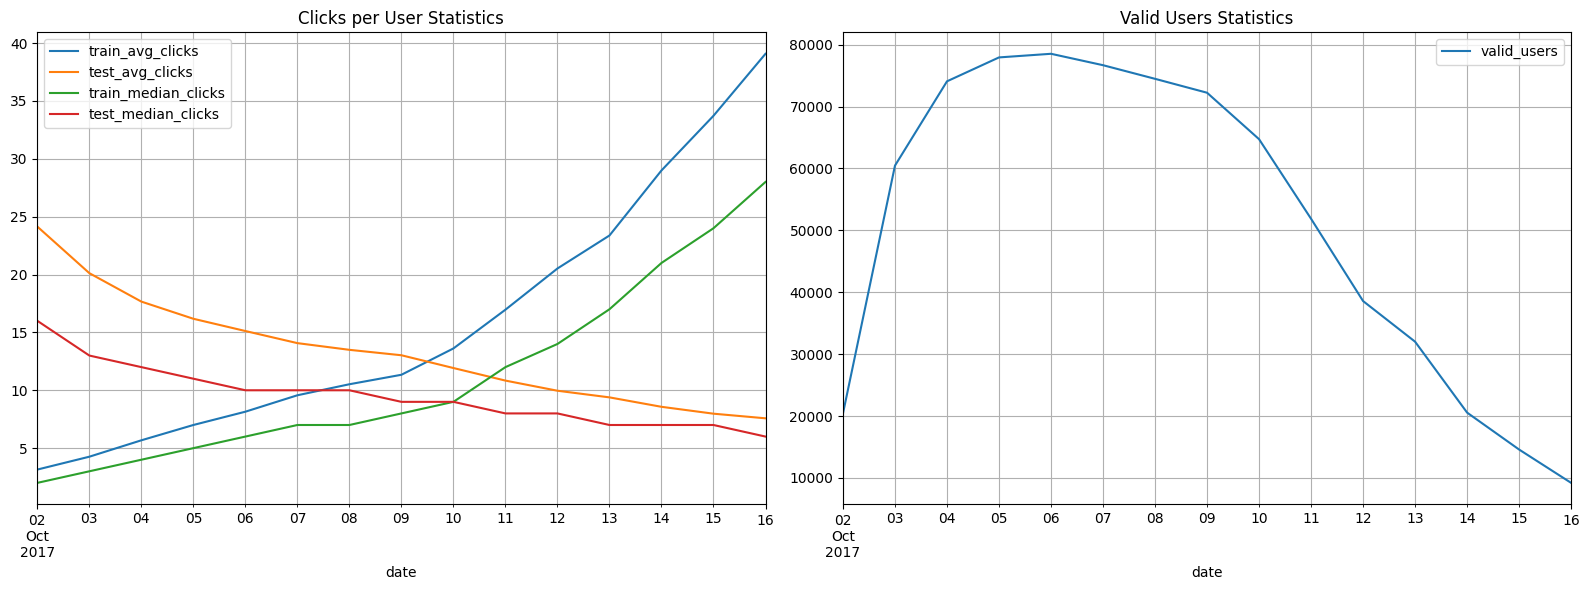

In [63]:
results_df = pd.DataFrame(results_dict).set_index("date")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot clicks per user stats
results_df.filter(like="click", axis=1).plot(ax=axes[0])
axes[0].set_title("Clicks per User Statistics")
axes[0].grid(visible=True, axis="both", which="both")

# Plot valid users stats
results_df.filter(like="user", axis=1).plot(ax=axes[1])
axes[1].set_title("Valid Users Statistics")
axes[1].grid(visible=True, axis="both", which="both")

plt.tight_layout()
plt.show()

In [ ]:
# Temporal train / test split
# - Test: [TEST_START, TEST_START + TEST_DAYS)  |  Train: clicks with timestamp < TEST_START
# - Users: >= MIN_TEST in test AND >= MIN_TRAIN in train
# - Saves train/test tables + aligned article embeddings for train ∪ test (row i ↔ article_id=i in pickle matrix)

from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np

TEST_DAYS = 7
MIN_TEST_CLICKS_PER_USER = 5
MIN_TRAIN_CLICKS_PER_USER = 1

_last_day = df["click_timestamp"].dt.floor("D").max()
TEST_START = _last_day - pd.Timedelta(days=TEST_DAYS - 1)
ts = df["click_timestamp"]
test_end = TEST_START + pd.Timedelta(days=TEST_DAYS)

mask_test = (ts >= TEST_START) & (ts < test_end)
mask_train = ts < TEST_START
df_test_raw = df.loc[mask_test].copy()
df_train_raw = df.loc[mask_train].copy()

clicks_test = df_test_raw.groupby("user_id", sort=False).size()
clicks_train = df_train_raw.groupby("user_id", sort=False).size()
user_ids_test = clicks_test[clicks_test >= MIN_TEST_CLICKS_PER_USER].index
user_ids_train = clicks_train[clicks_train >= MIN_TRAIN_CLICKS_PER_USER].index
valid_user_ids = user_ids_test.intersection(user_ids_train).sort_values()

df_test = df_test_raw[df_test_raw["user_id"].isin(valid_user_ids)].copy()
df_train = df_train_raw[df_train_raw["user_id"].isin(valid_user_ids)].copy()

clicks_test_f = df_test.groupby("user_id", sort=False).size()
clicks_train_f = df_train.groupby("user_id", sort=False).size()
assert len(clicks_test_f) == len(clicks_train_f) == len(valid_user_ids)

ITEM_COL = "article_id"

print(
    f"Test window: [{TEST_START} -> {test_end})  |  TEST_DAYS={TEST_DAYS} (UTC)\n"
    f"Raw rows — train: {len(df_train_raw):,}  |  test: {len(df_test_raw):,}\n"
    f"Valid users (test>={MIN_TEST_CLICKS_PER_USER}, train>={MIN_TRAIN_CLICKS_PER_USER}): {len(valid_user_ids):,}\n"
    f"Rows after filter — train: {len(df_train):,}  |  test: {len(df_test):,}\n"
)

summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "users": [len(clicks_train_f), len(clicks_test_f)],
        "clicks": [int(clicks_train_f.sum()), int(clicks_test_f.sum())],
        "mean_clicks_user": [clicks_train_f.mean(), clicks_test_f.mean()],
        "median_clicks_user": [clicks_train_f.median(), clicks_test_f.median()],
        "std_clicks_user": [clicks_train_f.std(), clicks_test_f.std()],
    }
)
display(summary)
print("Per-user click counts (after filter) — train:")
display(clicks_train_f.describe())
print("Per-user click counts (after filter) — test:")
display(clicks_test_f.describe())


def _notebook_project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "pyproject.toml").is_file():
            return p
    return (here.parent).resolve()


_ROOT = _notebook_project_root()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from loaders import DataLoader

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)


def _save_table(path_stem: Path, frame: pd.DataFrame) -> str:
    try:
        p = path_stem.with_suffix(".parquet")
        frame.to_parquet(p, index=False)
        return str(p)
    except Exception as e:
        p = path_stem.with_suffix(".csv.gz")
        frame.to_csv(p, index=False, compression="gzip")
        return f"{p} (parquet skipped: {type(e).__name__})"


p_train = _save_table(out_dir / "clicks_train_temporal", df_train)
p_test = _save_table(out_dir / "clicks_test_temporal", df_test)
print(f"Train: {p_train}\nTest:  {p_test}")

# Embeddings strictly aligned with article_id (dataset: row article_id exists in pickle)
_loader = DataLoader()
union_items = pd.Index(df_train[ITEM_COL]).union(df_test[ITEM_COL]).unique()

ids_emb, embeddings_subset = _loader.embeddings_aligned_to_article_ids(union_items, drop_out_of_range=True)

emb_bundle = out_dir / "article_embeddings_temporal_union.npz"
np.savez_compressed(
    emb_bundle,
    article_id=ids_emb.astype(np.int64),
    embedding=embeddings_subset.astype(np.float32),
)
print(
    f"Embeddings aligned to train ∪ test ({len(ids_emb):,} unique {ITEM_COL}): {emb_bundle}\n"
    f"  alignment: embedding[k] is the vector for article_id[k] "
    f"(sorted unique ids; example k=0 → id {ids_emb[0]})"
)

id_train_unique = df_train[ITEM_COL].nunique()
id_test_unique = df_test[ITEM_COL].nunique()

meta = {
    "test_start_utc": pd.Timestamp(TEST_START).isoformat(),
    "test_end_exclusive_utc": pd.Timestamp(test_end).isoformat(),
    "test_days": int(TEST_DAYS),
    "min_test_clicks_per_user": int(MIN_TEST_CLICKS_PER_USER),
    "min_train_clicks_per_user": int(MIN_TRAIN_CLICKS_PER_USER),
    "n_valid_users": int(len(valid_user_ids)),
    "train_rows": int(len(df_train)),
    "test_rows": int(len(df_test)),
    "n_unique_articles_train": int(id_train_unique),
    "n_unique_articles_test": int(id_test_unique),
    "n_unique_articles_union": int(len(ids_emb)),
    "embedding_dim": int(embeddings_subset.shape[1]),
    "article_embeddings_file": emb_bundle.name,
    "interaction_item_column": ITEM_COL,
    "embedding_alignment": "pickle matrix row index == article_id (contiguous ids in dataset)",
}

meta_path = out_dir / "temporal_split_meta.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)
print(f"Metadata: {meta_path}")


def describe_sliding_test_windows(
    df_: pd.DataFrame,
    first_test_start: pd.Timestamp,
    last_test_start: pd.Timestamp,
    test_days: int = 7,
    min_test: int = 5,
    min_train: int = 1,
) -> pd.DataFrame:
    """Optional: slide [TEST_START, TEST_START + test_days) one day at a time."""
    rows = []
    ts_ = df_["click_timestamp"]
    d = first_test_start.normalize()
    end_range = last_test_start.normalize()
    while d <= end_range:
        te = d + pd.Timedelta(days=test_days)
        m_t = (ts_ >= d) & (ts_ < te)
        m_tr = ts_ < d
        d_test = df_.loc[m_t]
        d_train = df_.loc[m_tr]
        ct = d_test.groupby("user_id", sort=False).size()
        cr = d_train.groupby("user_id", sort=False).size()
        uid = ct[ct >= min_test].index.intersection(cr[cr >= min_train].index)
        ft = d_test[d_test["user_id"].isin(uid)]
        ftr = d_train[d_train["user_id"].isin(uid)]
        ctf = ft.groupby("user_id", sort=False).size()
        ctt = ftr.groupby("user_id", sort=False).size()
        nu = int(uid.size)
        rows.append(
            {
                "test_start": d,
                "test_end_excl": te,
                "valid_users": nu,
                "train_rows": len(ftr),
                "test_rows": len(ft),
                "mean_clicks_user_train": ctt.mean() if nu else np.nan,
                "median_clicks_user_train": ctt.median() if nu else np.nan,
                "mean_clicks_user_test": ctf.mean() if nu else np.nan,
                "median_clicks_user_test": ctf.median() if nu else np.nan,
            }
        )
        d = d + pd.Timedelta(days=1)
    return pd.DataFrame(rows)


# sliding = describe_sliding_test_windows(
#     df,
#     first_test_start=pd.Timestamp("2017-10-01"),
#     last_test_start=pd.Timestamp("2017-10-11"),
#     test_days=TEST_DAYS,
#     min_test=MIN_TEST_CLICKS_PER_USER,
#     min_train=MIN_TRAIN_CLICKS_PER_USER,
# )
# display(sliding)


### Most popular articles

In [31]:
# find the top 10 most popular articles according to the number of clicks
top_articles = df['article_id'].value_counts().head(10).reset_index()
top_articles.columns = ['article_id', 'click_count']
# Add the category_id to the top_articles dataframe
top_articles = top_articles.merge(articles[['article_id', 'category_id']], on='article_id', how='left')
print(top_articles)

   article_id  click_count  category_id
0      160974        37213          281
1      272143        28943          399
2      336221        23851          437
3      234698        23499          375
4      123909        23122          250
5      336223        21855          437
6       96210        21577          209
7      162655        21062          281
8      183176        20303          301
9      168623        19526          297


In [27]:
# Most popular categories
top_categories = df['category_id'].value_counts().head(10).reset_index()
top_categories.columns = ['category_id', 'click_count']
print(top_categories)

   category_id  click_count
0          281       370843
1          375       268257
2          412       178894
3          437       157085
4          250       140454
5          331       115901
6          399       104464
7          209        83750
8          418        67119
9          118        64216


## Embeddings

In [22]:
print(f"Embeddings type : {type(embeddings)}")
print(f"Embeddings shape : {embeddings.shape}")
print(f"Show first Vector: \n {embeddings[0]}")

Embeddings type : <class 'numpy.ndarray'>
Embeddings shape : (364047, 250)
Show first Vector: 
 [-0.16118301 -0.95723313 -0.13794445  0.05085534  0.83005524  0.90136534
 -0.33514765 -0.55956066 -0.50060284  0.16518293  0.4284342   0.3550556
  0.87443674 -0.52888286  0.6254872   0.2689198  -0.8228351  -0.703853
 -0.62584543 -0.15285493 -0.6662412   0.04329487  0.1786375   0.04689008
  0.5945311  -0.18334764  0.19510683 -0.46763963 -0.30480695  0.35317516
  0.27818817  0.5386231  -0.37120935  0.48989806 -0.10383289  0.11917368
  0.13243659 -0.62108386 -0.45331132  0.34662652 -0.06174106 -0.7305939
 -0.38411567 -0.94075835  0.06134219  0.4825816   0.28968322 -0.62269634
 -0.05000444  0.42151213 -0.24257636  0.6687105  -0.509004   -0.46179956
  0.04390178  0.28848746  0.4498246  -0.28486234  0.916729    0.70312876
  0.85167396 -0.6272441   0.35773164  0.3901894   0.65293527  0.1036527
  0.79829276 -0.10254639 -0.2045143   0.37861153 -0.09026147 -0.2511573
  0.3259828   0.08588007 -0.180564

In [ ]:
# Are embeddings linked to article_id?
article_ids = articles['article_id'].tolist()
if len(article_ids) != len(embeddings):
    raise ValueError("⚠️ Articles count different from vectors count!")
else:
    print("Mapping articles to embedding vectors...")
    article_id_to_embedding = {
        aid: embeddings[i]
        for i, aid in enumerate(article_ids)
    }

sample_ids = np.random.choice(list(article_id_to_embedding.keys()), size=5, replace=False)
print("\n🧪 Articles vector sample:")
for aid in sample_ids:
    print(f"Article ID {aid} → Vector: {article_id_to_embedding[aid][:5]}")

Linking article_id to embedding...

🧪 Articles vector sample:
Article ID 116050 → Vector: [ 0.0222356  -0.96894425  0.86703503  0.18964642  0.49684027]
Article ID 21606 → Vector: [ 0.7392945  -0.9721414   0.26562148 -0.03987416  0.7360078 ]
Article ID 284820 → Vector: [-0.82959193 -0.96147203 -0.7257465  -0.79664785 -0.05611889]
Article ID 185674 → Vector: [ 0.6658226  -0.9718393   0.87091976 -0.36835253  0.35427257]
Article ID 119319 → Vector: [-0.50236034 -0.9650479   0.456096   -0.13546012  0.63662577]
